# Parliamentary Inquiry Text Mining Report

**Author:** Juan Vargas T.  
**Email:** juan.vargastorres@student.uts.edu.au  
**Website:** [https://jsebastianv.com](https://jsebastianv.com)

---


## Table of Contents

Use the links below to jump to each section.

0. [Utilities](#utilities)
   - [0.0 Environment setup](#utilities)
   - [0.1 Imports and package setup](#utilities)
   - [0.2 Global constants and visual theme](#utilities)
   - [0.3 Data models and metadata parsing classes](#utilities)
   - [0.4 Corpus ingestion service class](#utilities)
   - [0.5 Text preprocessing class and helper functions](#utilities)
1. [Introduction](#introduction)
2. [Data Ingestion](#data-ingestion)
3. [Exploratory Data Analysis](#exploratory-data-analysis)
   - [3.1 Corpus overview visuals](#exploratory-data-analysis)
   - [3.2 Corpus composition by submitter type](#exploratory-data-analysis)
   - [3.3 Distribution of document word counts](#exploratory-data-analysis)
   - [3.4 Relationship between pages and word counts](#exploratory-data-analysis)
   - [3.5 Character counts by submitter type](#exploratory-data-analysis)
   - [3.6 Part-of-Speech (POS) analysis](#exploratory-data-analysis)
4. [Preprocessing](#pre-processing)
   - [4.1 Prepare cleaned tokens and lexical metrics](#pre-processing)
   - [4.2 Most common words](#pre-processing)
   - [4.3 Corpus snapshot statistics](#pre-processing)
   - [4.4 Length comparison by submitter type](#pre-processing)
   - [4.5 Frequency table preparation (unigrams, NPMI bigrams, and NPMI trigrams)](#pre-processing)
   - [4.6 Top unigram frequency chart](#pre-processing)
   - [4.7 Top bigram frequency chart (using NPMI phrase output)](#pre-processing)
   - [4.8 Top three-gram frequency chart (using NPMI phrase output)](#pre-processing)
   - [4.9 Initial preprocessing interpretation](#pre-processing)
   - [4.10 Word cloud of preprocessed corpus](#pre-processing)
   - [4.11 Bigram network graph](#pre-processing)
5. [Advanced Methods (Topic Modeling / RegEx)](#topic-modeling)
   - [5.1 Topic modeling with LDA](#topic-modeling)
   - [5.2 Topic prevalence across submissions](#topic-modeling)
   - [5.3 RegEx pattern mining](#topic-modeling)
6. [Conclusion](#conclusion)
7. [References](#references)

---

<a id="utilities"></a>

## 0. Utilities

This section centralizes reusable setup so the rest of the notebook is clean and modular.

Utilities sub-sections are listed in the Table of Contents above.

### 0.0 Environment setup

Run this once per environment to install all required libraries from the project requirements file.

In [39]:
# 0.0 Install required libraries
%pip install -r requirements.txt

import sys
import subprocess

if sys.version_info < (3, 14):
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
else:
    print("spaCy model download skipped on Python 3.14+; NLTK fallback will be used for NER.")

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 5.8 MB/s  0:00:02m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


### 0.1 Imports and package setup

Load required Python libraries and NLTK resources used throughout the notebook.

In [40]:
# 0.1 Imports and package setup

from pathlib import Path
import re
import string
import logging
import sys
import subprocess
from dataclasses import dataclass
from collections import Counter
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from wordcloud import WordCloud

try:
    from pypdf import PdfReader
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pypdf"])
    from pypdf import PdfReader

try:
    from gensim.models.phrases import Phrases, Phraser
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gensim"])
    from gensim.models.phrases import Phrases, Phraser

try:
    import networkx as nx
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])
    import networkx as nx

import nltk
from nltk.corpus import stopwords, wordnet as wn
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

logging.getLogger("pypdf").setLevel(logging.ERROR)
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
LOGGER = logging.getLogger("nlp_report")


### 0.2 Global constants and visual theme

Define palette values, stopword settings, label mappings, and plotting defaults.

In [41]:
# 0.2 Global constants and visual theme

UTS_PALETTE = {
    "blue": "#0F4BEB",
    "red": "#FF2305",
    "black": "#000000",
    "dark_grey": "#323232",
    "mid_grey": "#B2B2B2",
    "light_grey": "#EBEBEB",
    "white": "#FFFFFF",
}

DOCS_DIR = Path("docs")
# DOMAIN_STOPWORDS contains words that are contextually frequent but not meaningful for semantic analysis
# in the parliamentary submissions corpus. These include words describing the process or context
# ("submission", "submissions", "inquiry", "committee", "electoral", "election", "federal", 
# "australian", "australia", "parliament") that do not add value for content-based text mining.
DOMAIN_STOPWORDS = {
    "submission", "submissions", "inquiry", "committee", "electoral",
    "election", "federal", "australian", "australia", "parliament"
}

# PUNCT_SET includes standard punctuation plus additional typographical marks and quotation variants
# that may occur in parliamentary submissions. This is to robustly detect and remove all forms of
# punctuation, including ellipses and different quote and dash styles, for thorough token cleaning.
PUNCT_SET = set(string.punctuation).union({
    "...", "''", "``", "’", "“", "”", "–", "—", ".", ","
})

SPACY_ENTITY_LABEL_DESCRIPTIONS = {
    "PERSON": "People, including fictional",
    "NORP": "Nationalities, Religious, or Political groups",
    "FAC": "Buildings, Airports, Highways, Bridges, etc.",
    "ORG": "Companies, Agencies, Institutions, etc.",
    "GPE": "Countries, Cities, States",
    "LOC": "Non-GPE locations, Mountain ranges, Bodies of water",
    "PRODUCT": "Objects, Vehicles, Foods, etc. (Not services)",
    "EVENT": "Named hurricanes, battles, wars, sports events, etc.",
    "WORK_OF_ART": "Titles of books, songs, etc.",
    "LAW": "Named documents made into laws",
    "LANGUAGE": "Any named language",
    "DATE": "Absolute or relative dates or periods",
    "TIME": "Times smaller than a day",
    "PERCENT": "Percentage",
    "MONEY": "Monetary values, including unit",
    "QUANTITY": "Measurements, as of weight or distance",
    "ORDINAL": "First, second, etc.",
    "CARDINAL": "Numerals that do not fall under another type",
}

ORG_NAME_INDICATORS = {
    "association", "assn", "institute", "foundation", "committee", "commission",
    "council", "union", "party", "group", "alliance", "network", "society",
    "organisation", "organization", "org", "company", "co", "corp", "corporation",
    "inc", "inc.", "ltd", "ltd.", "limited", "pty", "pty.", "trust", "church",
    "club", "board", "authority", "agency", "department", "office", "branch",
}
ORG_OVERRIDE_LABELS = {"NORP", "CARDINAL", "GPE"}

PENN_POS_TAG_MAP = {
    "CC": "Coordinating conjunction",
    "CD": "Cardinal number",
    "DT": "Determiner",
    "EX": "Existential there",
    "FW": "Foreign word",
    "IN": "Preposition/subordinating conjunction",
    "JJ": "Adjective",
    "JJR": "Adjective, comparative",
    "JJS": "Adjective, superlative",
    "LS": "List item marker",
    "MD": "Modal",
    "NN": "Noun, singular/common",
    "NNS": "Noun, plural",
    "NNP": "Proper noun, singular",
    "NNPS": "Proper noun, plural",
    "PDT": "Predeterminer",
    "POS": "Possessive ending",
    "PRP": "Personal pronoun",
    "PRP$": "Possessive pronoun",
    "RB": "Adverb",
    "RBR": "Adverb, comparative",
    "RBS": "Adverb, superlative",
    "RP": "Particle",
    "TO": "to",
    "UH": "Interjection",
    "VB": "Verb, base form",
    "VBD": "Verb, past tense",
    "VBG": "Verb, gerund/present participle",
    "VBN": "Verb, past participle",
    "VBP": "Verb, non-3rd person singular present",
    "VBZ": "Verb, 3rd person singular present",
    "WDT": "Wh-determiner",
    "WP": "Wh-pronoun",
    "WP$": "Possessive wh-pronoun",
    "WRB": "Wh-adverb",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.edgecolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["axes.labelcolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["text.color"] = UTS_PALETTE["dark_grey"]

NLP = None
try:
    import spacy
    NLP = spacy.load("en_core_web_sm")
    LOGGER.info("Spacy model successfuly loaded")

except Exception:
    LOGGER.warning("spaCy is unavailable in this Python environment; NLTK fallback will be used for NER.")

2026-03-09 13:07:46,426 | INFO | Spacy model successfuly loaded


### 0.3 Data models and metadata parsing classes

Define configuration/data classes and metadata parsing logic.

In [42]:
# 0.3 Data models and metadata parsing classes

@dataclass(frozen=True)
class CorpusConfig:
    """Configuration object for ingestion and basic corpus filtering."""
    docs_dir: Path
    min_word_count: int = 1

In [43]:
class MetadataParser:
    """Parses metadata and provides metadata-linked NER utilities."""

    @staticmethod
    def infer_submitter_type(name: str, nlp_model=None) -> str:
        """Infer submitter category from submitter name using spaCy NER labels."""
        lowered = name.lower()
        if "withheld" in lowered or "name withheld" in lowered or "withhold" in lowered:
            return "Withheld"

        model = nlp_model if nlp_model is not None else NLP
        if model is None:
            return "Unknown"

        doc = model(name)
        labels = [ent.label_ for ent in doc.ents if ent.label_]
        unique_labels = list(dict.fromkeys(labels))
        filtered_labels = [label for label in unique_labels if label != "DATE"]
        LOGGER.info(
            "spaCy NER labels for '%s': all=%s | filtered=%s",
            name,
            set(unique_labels),
            set(filtered_labels),
        )

        if not filtered_labels:
            # Fallback heuristic: infer organisation when common org tokens appear.
            if any(indicator in lowered for indicator in ORG_NAME_INDICATORS):
                return SPACY_ENTITY_LABEL_DESCRIPTIONS["ORG"]
            return "Unknown"

        # Keep a single label with priority: ORG > PERSON > first remaining.
        if "ORG" in filtered_labels:
            selected_label = "ORG"
        elif "PERSON" in filtered_labels:
            selected_label = "PERSON"
        else:
            selected_label = filtered_labels[0]

        if selected_label in ORG_OVERRIDE_LABELS:
            selected_label = "ORG"

        return SPACY_ENTITY_LABEL_DESCRIPTIONS.get(selected_label, selected_label)

    @staticmethod
    def parse_filename(file_name: str) -> tuple[str, str, str]:
        """Parse file name into submission id, submitter name, and submitter type."""
        base = file_name.replace(".pdf", "")
        id_match = re.match(r"^(SupSub\d+\.\d+|Sub\d+(?:\sAtt\d+)?)", base)
        submission_id = id_match.group(1) if id_match else "Unknown"

        parts = base.split(" - ", 1)
        submitter = parts[1].strip() if len(parts) > 1 else "Unknown"
        submitter_type = MetadataParser.infer_submitter_type(submitter)
        return submission_id, submitter, submitter_type

    @staticmethod
    def extract_named_entities(text_series: pd.Series, nlp_model=None, max_docs: int | None = 120) -> pd.DataFrame:
        """Extract named entities using spaCy when available, else fallback to NLTK chunking."""
        records = []
        iterable = text_series.head(max_docs) if max_docs is not None else text_series

        if nlp_model is not None:
            LOGGER.info("NER extraction started with spaCy (max_docs=%s)", max_docs)
            for doc_id, text in enumerate(iterable):
                doc = nlp_model(str(text))
                for ent in doc.ents:
                    if ent.text.strip():
                        records.append(
                            {
                                "doc_id": doc_id,
                                "entity": ent.text.strip(),
                                "label": ent.label_,
                            }
                        )
            LOGGER.info("NER extraction finished with spaCy: %d entities", len(records))
            return pd.DataFrame(records)

        LOGGER.info("spaCy unavailable; using NLTK fallback for NER (max_docs=%s)", max_docs)
        # NLTK fallback for environments where spaCy is unavailable
        for doc_id, text in enumerate(iterable):
            tokens = word_tokenize(str(text))
            if not tokens:
                continue

            tagged = pos_tag(tokens)
            chunks = ne_chunk(tagged, binary=False)

            for chunk in chunks:
                if hasattr(chunk, "label"):
                    entity_text = " ".join(token for token, _ in chunk.leaves()).strip()
                    if entity_text:
                        records.append(
                            {
                                "doc_id": doc_id,
                                "entity": entity_text,
                                "label": chunk.label(),
                            }
                        )

        return pd.DataFrame(records)

### 0.4 Corpus ingestion service class

Define the service that reads PDFs and builds ingestion records.

In [44]:
# 0.4 Corpus ingestion service class

class CorpusIngestionService:
    """Single-responsibility service for PDF extraction and corpus construction."""

    def __init__(self, config: CorpusConfig):
        """Initialize service with runtime corpus configuration."""
        self.config = config

    def extract_pdf_text(self, pdf_path: Path) -> tuple[str, int, bool]:
        """Extract text from a PDF and return text, page count, and extraction status."""
        text_parts = []
        page_count = 0
        extraction_ok = True

        try:
            reader = PdfReader(str(pdf_path))
            page_count = len(reader.pages)
            for page in reader.pages:
                text_parts.append(page.extract_text() or "")
        except Exception as exc:
            extraction_ok = False
            LOGGER.warning("Failed to extract PDF: %s | error=%s", pdf_path.name, exc)

        raw_text = "\n".join(text_parts).strip()
        return raw_text, page_count, extraction_ok

    def read_corpus(self) -> pd.DataFrame:
        """Read all submission PDFs and build a filtered corpus dataframe."""
        pdf_paths = sorted(self.config.docs_dir.glob("*.pdf"))
        if not pdf_paths:
            raise FileNotFoundError("No PDFs found in docs/. Confirm dataset path before continuing.")

        LOGGER.info("Starting corpus ingestion from %s (%d files)", self.config.docs_dir, len(pdf_paths))

        records = []
        for pdf_path in pdf_paths:
            submission_id, submitter, submitter_type = MetadataParser.parse_filename(pdf_path.name)
            raw_text, page_count, extraction_ok = self.extract_pdf_text(pdf_path)

            records.append(
                {
                    "file_name": pdf_path.name,
                    "submission_id": submission_id,
                    "submitter": submitter,
                    "submitter_type": submitter_type,
                    "n_pages": page_count,
                    "extraction_ok": extraction_ok,
                    "raw_text": raw_text,
                }
            )

        corpus_df = pd.DataFrame(records)
        corpus_df["raw_text"] = corpus_df["raw_text"].fillna("")
        corpus_df["char_count"] = corpus_df["raw_text"].str.len()
        corpus_df["word_count_raw"] = corpus_df["raw_text"].str.split().str.len()

        filtered_df = corpus_df[corpus_df["word_count_raw"] >= self.config.min_word_count].reset_index(drop=True)
        LOGGER.info("Corpus ingestion complete: %d usable documents", len(filtered_df))
        return filtered_df

### 0.5 Text preprocessing class and helper functions

Define preprocessing utilities, chart helpers, and reusable analysis functions.

In [45]:
class TextPreprocessor:
    """Encapsulates token cleaning, phrase detection, and later lemmatization rules."""

    def __init__(self, domain_stopwords: set[str], punct_set: set[str]):
        """Build stopword, punctuation, and lemmatization resources."""
        base_stopwords = set(stopwords.words("english"))
        self.stop_words = base_stopwords.union(domain_stopwords)
        self.punct_set = punct_set
        self.lemmatizer = WordNetLemmatizer()

    @staticmethod
    def map_pos_tag(tag: str) -> str:
        """Map Penn Treebank tags to the WordNet tags used by the lemmatizer."""
        if tag.startswith("J"):
            return wn.ADJ
        if tag.startswith("V"):
            return wn.VERB
        if tag.startswith("R"):
            return wn.ADV
        return wn.NOUN

    def clean_tokens(self, text: str) -> list[str]:
        """Convert raw text into normalized and filtered alphabetic tokens without lemmatizing."""
        tokens = word_tokenize(text.lower())
        return [
            token for token in tokens
            if token not in self.stop_words
            and token not in self.punct_set
            and token.isalpha()
            and len(token) > 2
        ]

    @staticmethod
    def fit_pmi_bigram_model(token_sequences: Iterable[list[str]], min_count: int = 3, threshold: float = 0.6) -> Phraser:
        """Fit an NPMI-scored bigram phrase model on cleaned token sequences."""
        phrases = Phrases(
            token_sequences,
            min_count=min_count,
            threshold=threshold,
            scoring="npmi",
        )
        return Phraser(phrases)

    @staticmethod
    def fit_pmi_trigram_model(token_sequences: Iterable[list[str]], min_count: int = 3, threshold: float = 0.6) -> Phraser:
        """Fit an NPMI-scored trigram phrase model on bigram-transformed token sequences."""
        phrases = Phrases(
            token_sequences,
            min_count=min_count,
            threshold=threshold,
            scoring="npmi",
        )
        return Phraser(phrases)

    @staticmethod
    def apply_phrase_model(tokens: list[str], phrase_model: Phraser) -> list[str]:
        """Apply a trained phrase model to one token list."""
        if not tokens:
            return []
        return list(phrase_model[tokens])

    def lemmatize_tokens(self, tokens: list[str]) -> list[str]:
        """Lemmatize an already cleaned or phrase-detected token list after collocation analysis."""
        if not tokens:
            return []

        tagged_tokens = pos_tag(tokens)
        return [
            self.lemmatizer.lemmatize(token, self.map_pos_tag(tag))
            for token, tag in tagged_tokens
        ]


In [46]:
class TextAnalytics:
    """Collect reusable analytics helpers so notebook methods stay class-scoped."""

    @staticmethod
    def compute_ngram_counts(token_sequences: Iterable[list[str]], n: int = 2) -> Counter:
        """Compute n-gram frequencies from tokenized documents."""
        return Counter(gram for tokens in token_sequences for gram in ngrams(tokens, n))

    @staticmethod
    def extract_top_terms_per_topic(model: LatentDirichletAllocation, feature_names: np.ndarray, top_n: int = 10) -> pd.DataFrame:
        """Return a dataframe containing top terms for each topic in an LDA model."""
        topic_rows = []
        for topic_idx, topic_weights in enumerate(model.components_):
            top_indices = topic_weights.argsort()[::-1][:top_n]
            topic_rows.append(
                {
                    "topic": f"Topic {topic_idx + 1}",
                    "top_terms": ", ".join(feature_names[top_indices]),
                }
            )
        return pd.DataFrame(topic_rows)

    @staticmethod
    def extract_regex_counts(text_series: pd.Series, pattern: str) -> pd.Series:
        """Extract regex matches from text series and return sorted frequency counts."""
        matches = text_series.str.findall(pattern)
        flattened = [item for sublist in matches for item in sublist]
        return pd.Series(flattened).value_counts()


In [47]:
class Visuals:
    """Reusable plotting helper for consistent chart styling and labeling."""

    def __init__(self, palette: dict[str, str]):
        """Initialize chart helper with a shared color palette."""
        self.palette = palette

    def bar(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str, color: str | None = None,
            hue: str | None = None, palette=None, figsize: tuple[int, int] = (10, 6), ax=None,
            gradient_by_value: bool = True, alpha_min: float = 0.25, alpha_max: float = 0.95):
        """Draw a configurable vertical bar chart with optional value-based opacity gradient."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.barplot(data=data, x=x, y=y, color=color, hue=hue, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        # Apply a gradient where higher values are rendered with higher opacity.
        if gradient_by_value and ax.patches:
            bar_values = [max(patch.get_width(), patch.get_height()) for patch in ax.patches]
            min_val = min(bar_values)
            max_val = max(bar_values)

            for patch, value in zip(ax.patches, bar_values):
                if max_val == min_val:
                    alpha = (alpha_min + alpha_max) / 2
                else:
                    scale = (value - min_val) / (max_val - min_val)
                    alpha = alpha_min + (scale * (alpha_max - alpha_min))
                patch.set_alpha(alpha)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def hist(self, series: pd.Series, title: str, xlabel: str, ylabel: str, bins: int = 30,
             color: str | None = None, edgecolor: str | None = None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable histogram from a series."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.histplot(series, bins=bins, color=color, edgecolor=edgecolor, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def box(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
            palette=None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable boxplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def scatter(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
                hue: str | None = None, palette=None, alpha: float = 0.7,
                figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable scatterplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def bigram_network(self, tokens: list[str], title: str, n: int = 50, figsize: tuple[int, int] = (16, 12)):
        """Draw a bigram network graph from a token stream using the shared palette."""
        bigram_freq = Counter(ngrams(tokens, 2))
        if not bigram_freq:
            print("Not enough tokens to draw a bigram network.")
            return

        graph = nx.Graph()
        edge_weights = []
        for bigram, count in bigram_freq.most_common(n):
            graph.add_edge(bigram[0], bigram[1], weight=count)
            edge_weights.append(count)

        if not edge_weights:
            print("No bigrams available to draw.")
            return

        edge_weights_array = np.array(edge_weights, dtype=float)
        if edge_weights_array.max() == edge_weights_array.min():
            edge_widths = np.full_like(edge_weights_array, 3.0)
        else:
            edge_widths = 1 + (edge_weights_array - edge_weights_array.min()) * 5 / (
                edge_weights_array.max() - edge_weights_array.min()
            )

        edge_cmap = LinearSegmentedColormap.from_list(
            "uts_bigram_edges",
            [self.palette["light_grey"], self.palette["blue"]],
        )
        norm = Normalize(vmin=edge_weights_array.min(), vmax=edge_weights_array.max())

        fig, ax = plt.subplots(figsize=figsize)
        pos = nx.spring_layout(graph, k=0.5, iterations=50, seed=42)

        nx.draw_networkx_nodes(
            graph,
            pos,
            node_size=1000,
            node_color=self.palette["light_grey"],
            edgecolors=self.palette["dark_grey"],
            linewidths=1.0,
            ax=ax,
        )
        nx.draw_networkx_edges(
            graph,
            pos,
            width=edge_widths,
            edge_color=edge_weights_array,
            edge_cmap=edge_cmap,
            edge_vmin=edge_weights_array.min(),
            edge_vmax=edge_weights_array.max(),
            alpha=0.9,
            ax=ax,
        )
        nx.draw_networkx_labels(
            graph,
            pos,
            font_size=10,
            font_weight="bold",
            font_color=self.palette["dark_grey"],
            ax=ax,
        )

        ax.set_title(title, color=self.palette["dark_grey"])
        ax.axis("off")

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label("Edge Weight (Bigram Frequency)", color=self.palette["dark_grey"])
        cbar.ax.yaxis.set_tick_params(color=self.palette["dark_grey"])
        plt.setp(cbar.ax.get_yticklabels(), color=self.palette["dark_grey"])

        plt.tight_layout()
        plt.show()

    def wordcloud(self, text: str, title: str, width: int = 1200, height: int = 500, max_words: int = 150,
                  colormap: str = "Blues", background_color: str | None = None, figsize: tuple[int, int] = (14, 6)):
        """Draw a word cloud from input text with consistent notebook styling."""
        cloud = WordCloud(
            width=width,
            height=height,
            max_words=max_words,
            colormap=colormap,
            collocations=False,
            background_color=background_color or self.palette["white"],
        ).generate(text)

        plt.figure(figsize=figsize)
        plt.imshow(cloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, color=self.palette["dark_grey"])
        plt.tight_layout()
        plt.show()

<a id="introduction"></a>

## 1. Introduction

This report analyses public submissions to the Australian parliamentary inquiry into the conduct of the 2025 federal election. Parliamentary inquiries play an important role in democratic policy development by collecting evidence from individuals and organisations and translating that evidence into recommendations for parliament. Using Natural Language Processing (NLP), this project transforms a large PDF-based corpus of submissions into interpretable insights about dominant concerns, recurring themes, and language patterns in public perspectives.

The analysis aims to answer three core questions: (1) What topics and issues appear most frequently across submissions? (2) How do linguistic patterns vary across different submitter types or submission groups inferred from metadata? and (3) What evidence-based insights can be communicated clearly to non-technical audiences? To address these questions, the workflow combines text extraction, preprocessing, exploratory analysis, and method-driven modeling with visual interpretation and plain-language reporting.

<a id="data-ingestion"></a>

## 2. Data Ingestion

### Section Focus

This section loads all PDF submissions from `docs/`, extracts document text, and builds a structured corpus table for downstream NLP analysis.

**What this ingestion step delivers:**
- one row per submission document,
- metadata parsed from filenames (submission ID, submitter label, simple submitter type),
- extraction diagnostics (page count, extraction status),
- text-length features (character and word counts),
- a clean `corpus_df` dataframe used in all later analysis sections.

In [48]:
# 2.0 Data ingestion execution: build corpus dataframe using configured services

config = CorpusConfig(docs_dir=DOCS_DIR, min_word_count=1)
ingestion_service = CorpusIngestionService(config)
preprocessor = TextPreprocessor(domain_stopwords=DOMAIN_STOPWORDS, punct_set=PUNCT_SET)
visuals = Visuals(UTS_PALETTE)

corpus_df = ingestion_service.read_corpus()

LOGGER.info("Documents discovered: %d", len(list(DOCS_DIR.glob('*.pdf'))))
LOGGER.info("Documents with extracted text: %d", len(corpus_df))
LOGGER.info("Submitter type counts:\n%s", corpus_df["submitter_type"].value_counts())

print(f"Documents discovered: {len(list(DOCS_DIR.glob('*.pdf')))}")
print(f"Documents with extracted text: {len(corpus_df)}")
print("\nSubmitter type counts:")
print(corpus_df["submitter_type"].value_counts())

corpus_df.head(5)

2026-03-09 13:07:46,476 | INFO | Starting corpus ingestion from docs (299 files)
2026-03-09 13:07:46,487 | INFO | spaCy NER labels for 'Bob McMullan': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 13:07:46,527 | INFO | spaCy NER labels for 'Dr Sheppard': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 13:07:46,649 | INFO | spaCy NER labels for 'Grattan Institute': all={'ORG'} | filtered={'ORG'}
2026-03-09 13:07:47,139 | INFO | spaCy NER labels for 'Australian Electoral Commission': all={'ORG'} | filtered={'ORG'}
2026-03-09 13:07:47,885 | INFO | spaCy NER labels for 'The Australia Institute': all={'ORG'} | filtered={'ORG'}
2026-03-09 13:07:48,458 | INFO | spaCy NER labels for 'Andrew Murray': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 13:07:48,478 | INFO | spaCy NER labels for 'Genevieve Grant': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 13:07:48,500 | INFO | spaCy NER labels for 'Richard Ure': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 13:07:48,513 | INFO | spaCy NER l

Documents discovered: 299
Documents with extracted text: 299

Submitter type counts:
submitter_type
People, including fictional                132
Withheld                                    99
Companies, Agencies, Institutions, etc.     53
Unknown                                     15
Name: count, dtype: int64


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
0,Sub001 - Bob McMullan.pdf,Sub001,Bob McMullan,"People, including fictional",2,True,Time to revisit territory representation \nInt...,4131,662
1,Sub002 - Dr Sheppard.pdf,Sub002,Dr Sheppard,"People, including fictional",4,True,Inquiry into the 2025 federal election\nSubmis...,4990,782
2,Sub003 - Grattan Institute.pdf,Sub003,Grattan Institute,"Companies, Agencies, Institutions, etc.",13,True,Submission to the Inquiry into the 2025 federa...,35242,4804
3,Sub004 - Australian Electoral Commission.pdf,Sub004,Australian Electoral Commission,"Companies, Agencies, Institutions, etc.",19,True,AEC SUBMISSION \nJoint Standing Committee on E...,68568,10131
4,Sub005 - The Australia Institute.pdf,Sub005,The Australia Institute,"Companies, Agencies, Institutions, etc.",55,True,Australian democracy in \n2025 \nSubmission to...,90092,12137


<a id="exploratory-data-analysis"></a>

## 3. Exploratory Data Analysis

### Section Focus

Following the Week 1 guidance (word counts, frequent terms, and cleaned-token patterns), this section establishes high-level corpus behavior before advanced modeling.

**EDA outputs included below:**
- document-length distribution (histogram + grouped boxplot),
- cleaned-token vocabulary size and lexical diversity,
- top unigrams and bigrams after stopword and punctuation filtering,
- simple submitter-type comparison using filename-derived metadata,
- quick observations to motivate subsequent preprocessing and topic methods.


### 3.1 Corpus overview visuals

This subsection provides a high-level visual overview of the corpus dataframe before detailed token analysis. Charts summarize corpus composition, document scale, and key structural relationships across submissions.

In [49]:
# 3.1 Overview statistics table

overview_stats = corpus_df[["n_pages", "char_count", "word_count_raw"]].describe().T
display(overview_stats)

,count,mean,std,min,25%,50%,75%,max
n_pages,299.0,6.615385,12.334375,1.0,2.0,3.0,6.0,120.0
char_count,299.0,13212.842809,25405.188038,52.0,2084.5,5175.0,11669.5,226824.0
word_count_raw,299.0,2052.381271,4055.464684,8.0,344.5,815.0,1831.5,36278.0


### 3.2 Corpus composition by submitter type

This chart shows how many submissions come from each inferred submitter category.

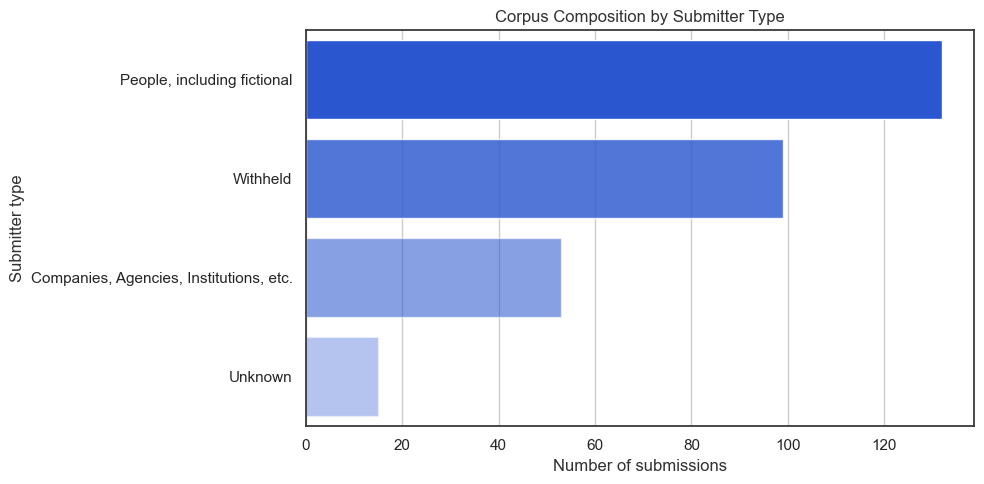

In [50]:
# 3.2 Visual: corpus composition by submitter type

submitter_counts = (
    corpus_df["submitter_type"]
    .value_counts()
    .rename_axis("submitter_type")
    .reset_index(name="count")
)

visuals.bar(
    data=submitter_counts,
    x="count",
    y="submitter_type",
    title="Corpus Composition by Submitter Type",
    xlabel="Number of submissions",
    ylabel="Submitter type",
    color=UTS_PALETTE["blue"],
    gradient_by_value=True,
    alpha_min=0.35,
    alpha_max=1.0,
    figsize=(10, 5),
)

**Analysis.** The corpus is not evenly distributed across submitter types, so later comparisons should be read with both document counts and document lengths in mind. If one category contributes many more submissions than another, simple frequency totals can reflect corpus composition as much as substantive differences in viewpoint.

### 3.3 Distribution of document word counts

This histogram shows the spread of document sizes across submissions.

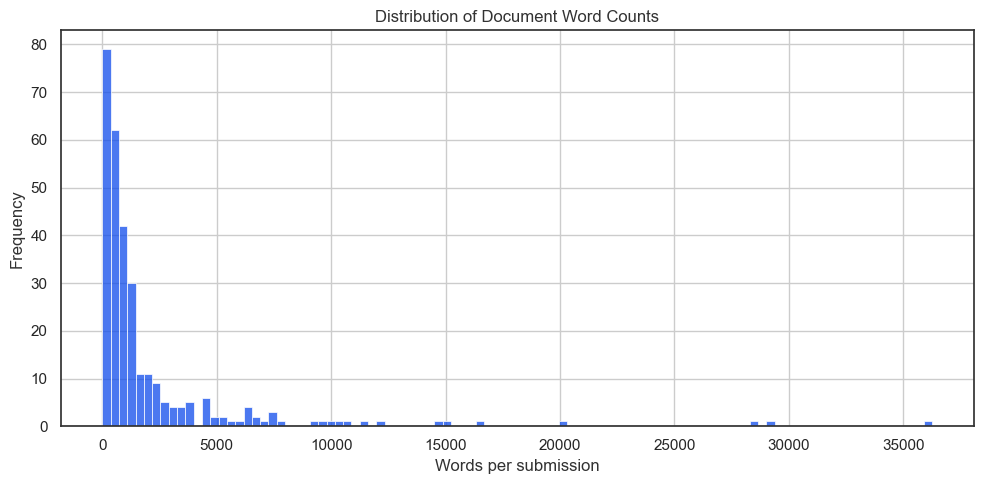

In [51]:
# 3.3 Visual: word-count distribution

visuals.hist(
    series=corpus_df["word_count_raw"],
    bins=100,
    color=UTS_PALETTE["blue"],
    edgecolor=UTS_PALETTE["white"],
    title="Distribution of Document Word Counts",
    xlabel="Words per submission",
    ylabel="Frequency",
    figsize=(10, 5),
)

**Analysis.** Most submissions appear to cluster at the lower end of the distribution, while a long right tail captures a much smaller set of very large documents. This confirms the corpus is highly skewed and helps explain why the median document length is more representative than the mean for describing a typical submission.

In [52]:
# Find and show the entire row for the document with the largest word count
max_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmax()]
print("Document with the largest word count (entire row):")
display(max_word_count_row.to_frame().T)

# Find and show the entire row for the document with the smallest word count
min_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmin()]
print("Document with the smallest word count (entire row):")
display(min_word_count_row.to_frame().T)

Document with the largest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
140,Sub141 Att1 - Malcolm Mackerras.pdf,Sub141 Att1,Malcolm Mackerras,"People, including fictional",96,True,Inquiry into the 2025 federal election\nSubmis...,215643,36278


Document with the smallest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
14,Sub015 - Name withheld.pdf,Sub015,Name withheld,Withheld,1,True,Inquiry into the 2025 federal election\nSubmis...,52,8


### 3.4 Relationship between pages and word counts

This scatter plot compares page counts with total words to show document scale relationships.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_67245/1774401529.py:87: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)


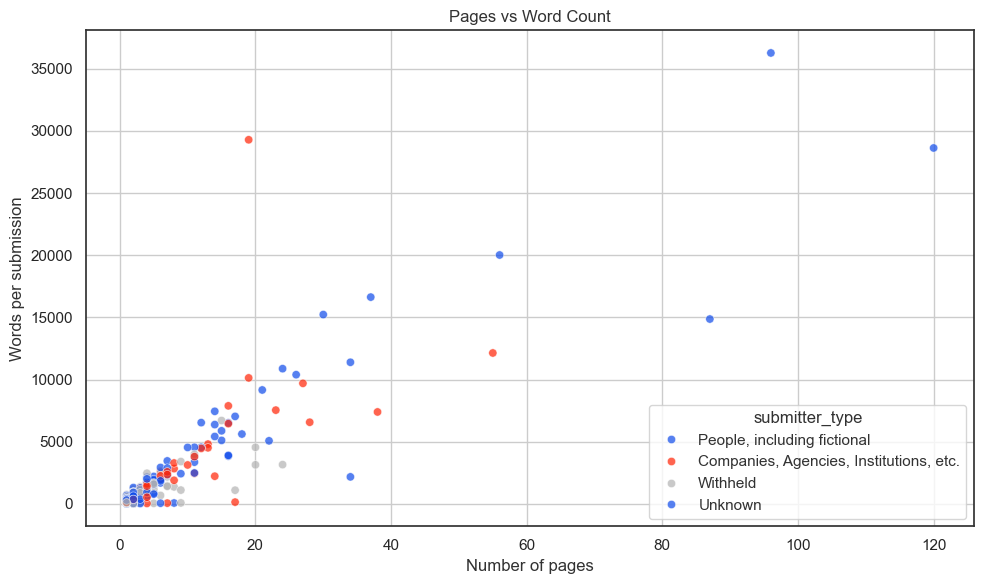

In [53]:
# 3.4 Visual: pages vs word counts

visuals.scatter(
    data=corpus_df,
    x="n_pages",
    y="word_count_raw",
    hue="submitter_type",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    alpha=0.7,
    title="Pages vs Word Count",
    xlabel="Number of pages",
    ylabel="Words per submission",
    figsize=(10, 6),
)

**Analysis.** Word count generally increases with page count, which suggests the extracted text volume broadly matches document length. At the same time, the spread at similar page totals shows that formatting and document style still matter, so page count should be treated as an approximate rather than exact proxy for textual richness.

### 3.5 Character counts by submitter type

This boxplot compares character-count distributions by submitter category.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_67245/1774401529.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_67245/1774401529.py:68: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)


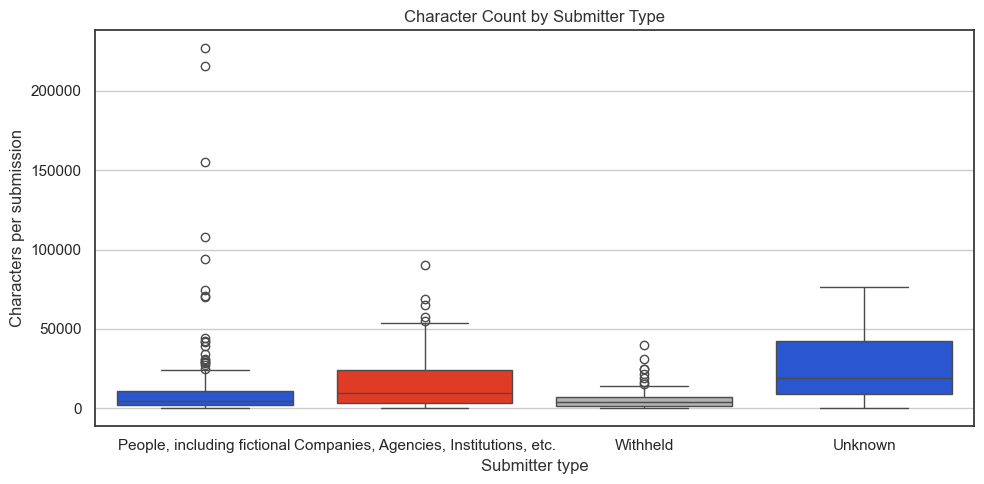

In [54]:
# 3.5 Visual: character count by submitter type

visuals.box(
    data=corpus_df,
    x="submitter_type",
    y="char_count",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    title="Character Count by Submitter Type",
    xlabel="Submitter type",
    ylabel="Characters per submission",
    figsize=(10, 5),
)

**Analysis.** Character counts vary substantially within and across submitter types, showing that some groups contribute much more text than others. This reinforces the need to use robust summary statistics and, where appropriate, normalized text measures so that the largest submissions do not dominate every downstream comparison.

### 3.6 Part-of-Speech (POS) analysis

This cell tags words in submission text using NLTK POS tagging (on a capped sample for runtime) and summarizes the most frequent grammatical categories.

2026-03-09 13:08:29,375 | INFO | POS tagging complete: docs=120, tagged_tokens=207648


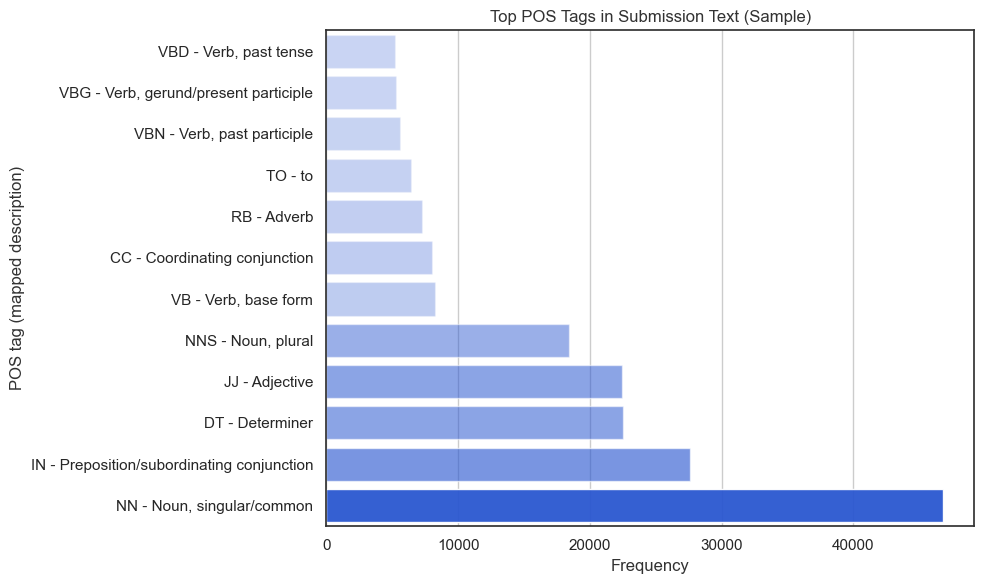

,pos_tag,pos_description,count
11,VBD,"Verb, past tense",5177
10,VBG,"Verb, gerund/present participle",5316
9,VBN,"Verb, past participle",5620
8,TO,to,6399
7,RB,Adverb,7223
6,CC,Coordinating conjunction,8050
5,VB,"Verb, base form",8241
4,NNS,"Noun, plural",18441
3,JJ,Adjective,22461
2,DT,Determiner,22483


In [55]:
# 3.6 POS analysis: top grammatical tags

pos_max_docs = 120
pos_tags = []

for text in corpus_df["raw_text"].head(pos_max_docs):
    tokens = [token.lower() for token in word_tokenize(str(text)) if token.isalpha()]
    if not tokens:
        continue
    pos_tags.extend(tag for _, tag in pos_tag(tokens))

pos_tag_counts = pd.Series(pos_tags, name="pos_tag").value_counts().reset_index()
pos_tag_counts.columns = ["pos_tag", "count"]
pos_tag_counts["pos_description"] = pos_tag_counts["pos_tag"].map(PENN_POS_TAG_MAP).fillna("Other/Unknown")
pos_tag_counts["pos_label"] = pos_tag_counts["pos_tag"] + " - " + pos_tag_counts["pos_description"]

top_pos_tags = pos_tag_counts.head(12).sort_values("count", ascending=True)

LOGGER.info(
    "POS tagging complete: docs=%d, tagged_tokens=%d",
    min(pos_max_docs, len(corpus_df)),
    len(pos_tags),
)

visuals.bar(
    data=top_pos_tags,
    x="count",
    y="pos_label",
    color=UTS_PALETTE["blue"],
    title="Top POS Tags in Submission Text (Sample)",
    xlabel="Frequency",
    ylabel="POS tag (mapped description)",
    figsize=(10, 6),
)

top_pos_tags[["pos_tag", "pos_description", "count"]]

**Analysis.** Nouns, prepositions, determiners, and adjectives dominate the POS profile, which is typical of formal submissions that describe institutions, actors, and relationships in detail. This pattern suggests the corpus is rich enough for topical term analysis, although the POS results come from a sample of documents rather than the full collection.

<a id="pre-processing"></a>

## 4. Preprocessing

### 4.1 Prepare cleaned tokens and lexical metrics

This cell applies the preprocessing rules, creates cleaned token lists per document, and computes reusable corpus-level metrics such as cleaned word counts and lexical diversity.


In [56]:
# 4.1 Tokenization output and document-level lexical features

corpus_df["raw_tokens"] = corpus_df["raw_text"].apply(
    lambda text: [token.lower() for token in word_tokenize(str(text)) if token.isalpha() and len(token) > 2]
)
corpus_df["clean_tokens"] = corpus_df["raw_text"].apply(preprocessor.clean_tokens)

bigram_model = preprocessor.fit_pmi_bigram_model(corpus_df["clean_tokens"], min_count=3, threshold=0.6)
corpus_df["pmi_bigram_tokens"] = corpus_df["clean_tokens"].apply(
    lambda tokens: preprocessor.apply_phrase_model(tokens, bigram_model)
)

trigram_model = preprocessor.fit_pmi_trigram_model(corpus_df["pmi_bigram_tokens"], min_count=3, threshold=0.6)
corpus_df["pmi_trigram_tokens"] = corpus_df["pmi_bigram_tokens"].apply(
    lambda tokens: preprocessor.apply_phrase_model(tokens, trigram_model)
)

corpus_df["lemmatized_tokens"] = corpus_df["pmi_trigram_tokens"].apply(preprocessor.lemmatize_tokens)
corpus_df["preprocessed_text"] = corpus_df["lemmatized_tokens"].apply(" ".join)

corpus_df["clean_word_count"] = corpus_df["clean_tokens"].str.len()
corpus_df["lexical_diversity"] = corpus_df.apply(
    lambda r: (len(set(r["clean_tokens"])) / r["clean_word_count"]) if r["clean_word_count"] > 0 else np.nan,
    axis=1,
)

raw_all_tokens = [token for tokens in corpus_df["raw_tokens"] for token in tokens]
all_tokens = [token for tokens in corpus_df["clean_tokens"] for token in tokens]
pmi_bigram_vocab = {token for tokens in corpus_df["pmi_bigram_tokens"] for token in tokens}
pmi_trigram_vocab = {token for tokens in corpus_df["pmi_trigram_tokens"] for token in tokens}
lemmatized_vocab = {token for tokens in corpus_df["lemmatized_tokens"] for token in tokens}
vocab_size = len(set(all_tokens))
LOGGER.info(
    "Tokenization complete: raw_vocab_size=%d, clean_vocab_size=%d, bigram_vocab_size=%d, trigram_vocab_size=%d, lemmatized_vocab_size=%d, docs=%d",
    len(set(raw_all_tokens)),
    vocab_size,
    len(pmi_bigram_vocab),
    len(pmi_trigram_vocab),
    len(lemmatized_vocab),
    len(corpus_df),
)

corpus_df[["file_name", "clean_tokens", "pmi_bigram_tokens", "pmi_trigram_tokens", "lemmatized_tokens"]].head(10)


2026-03-09 13:08:32,176 | INFO | collecting all words and their counts
2026-03-09 13:08:32,176 | INFO | PROGRESS: at sentence #0, processed 0 words and 0 word types
2026-03-09 13:08:32,346 | INFO | collected 199579 token types (unigram + bigrams) from a corpus of 271039 words and 299 sentences
2026-03-09 13:08:32,346 | INFO | merged Phrases<199579 vocab, min_count=3, threshold=0.6, max_vocab_size=40000000>
2026-03-09 13:08:32,346 | INFO | Phrases lifecycle event {'msg': 'built Phrases<199579 vocab, min_count=3, threshold=0.6, max_vocab_size=40000000> in 0.17s', 'datetime': '2026-03-09T13:08:32.346778', 'gensim': '4.4.0', 'python': '3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]', 'platform': 'macOS-26.1-arm64-arm-64bit', 'event': 'created'}
2026-03-09 13:08:32,347 | INFO | exporting phrases from Phrases<199579 vocab, min_count=3, threshold=0.6, max_vocab_size=40000000>
2026-03-09 13:08:32,498 | INFO | FrozenPhrases lifecycle event {'msg': 'expor

,file_name,clean_tokens,pmi_bigram_tokens,pmi_trigram_tokens,lemmatized_tokens
0,Sub001 - Bob McMullan.pdf,"[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int..."
1,Sub002 - Dr Sheppard.pdf,"[national, university, possible, solutions, mo...","[national, university, possible, solutions, mo...","[national, university, possible, solutions, mo...","[national, university, possible, solution, mon..."
2,Sub003 - Grattan Institute.pdf,"[grattan, institute, september, aruna, sathana...","[grattan_institute, september, aruna, sathanap...","[grattan_institute, september, aruna, sathanap...","[grattan_institute, september, aruna, sathanap..."
3,Sub004 - Australian Electoral Commission.pdf,"[aec, joint, standing, matters, aec, joint, st...","[aec, joint_standing, matters, aec, joint_stan...","[aec, joint_standing_matters, aec, joint_stand...","[aec, joint_standing_matters, aec, joint_stand..."
4,Sub005 - The Australia Institute.pdf,"[democracy, thriving, inventive, democracy, me...","[democracy, thriving, inventive, democracy, me...","[democracy, thriving, inventive, democracy, me...","[democracy, thrive, inventive, democracy, meas..."
5,Sub006 - Andrew Murray.pdf,"[secretary, joint, standing, matters, box, hou...","[secretary_joint, standing_matters, box, house...","[secretary_joint_standing_matters, box, house,...","[secretary_joint_standing_matters, box, house,..."
6,Sub007 - Genevieve Grant.pdf,"[page, written, joint, standing, matters, refe...","[page, written, joint_standing, matters, refer...","[page, written, joint_standing_matters, refere...","[page, write, joint_standing_matters, referenc..."
7,Sub008 - Richard Ure.pdf,"[ten, years, ago, epping, ﬁrst, suburb, sydney...","[ten, years_ago, epping, ﬁrst, suburb, sydney,...","[ten, years_ago, epping, ﬁrst, suburb, sydney,...","[ten, years_ago, epping, ﬁrst, suburb, sydney,..."
8,Sub009 - Barry Searle.pdf,"[barry, searle, sept, time, banned, poll, boot...","[barry, searle, sept, time, banned, poll, boot...","[barry, searle, sept, time, banned, poll, boot...","[barry, searle, sept, time, ban, poll, booth, ..."
9,Sub010 - Name withheld.pdf,"[regarding, brief, voted, day, polling, ended,...","[regarding, brief, voted, day, polling, ended,...","[regarding, brief, voted, day, polling, ended,...","[regard, brief, vote, day, polling, end, wait,..."


### 4.2 Most common words

This subsection focuses on visualization only. Using the cleaned tokens prepared in the previous step, it shows the most common terms across the full corpus and within each `submitter_type`.


2026-03-09 13:08:40,713 | INFO | Clean token visualization prepared: unique_clean_tokens=16666


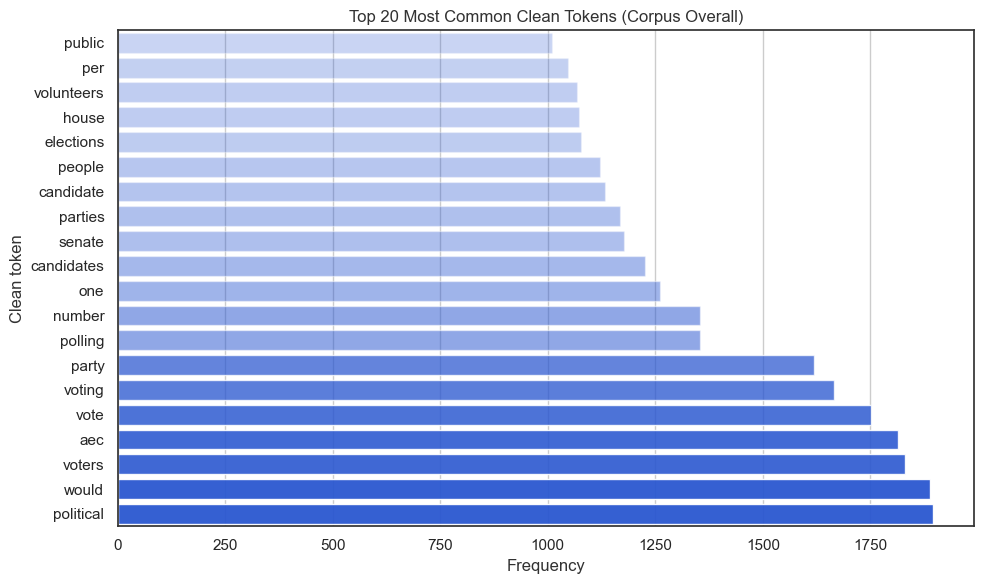

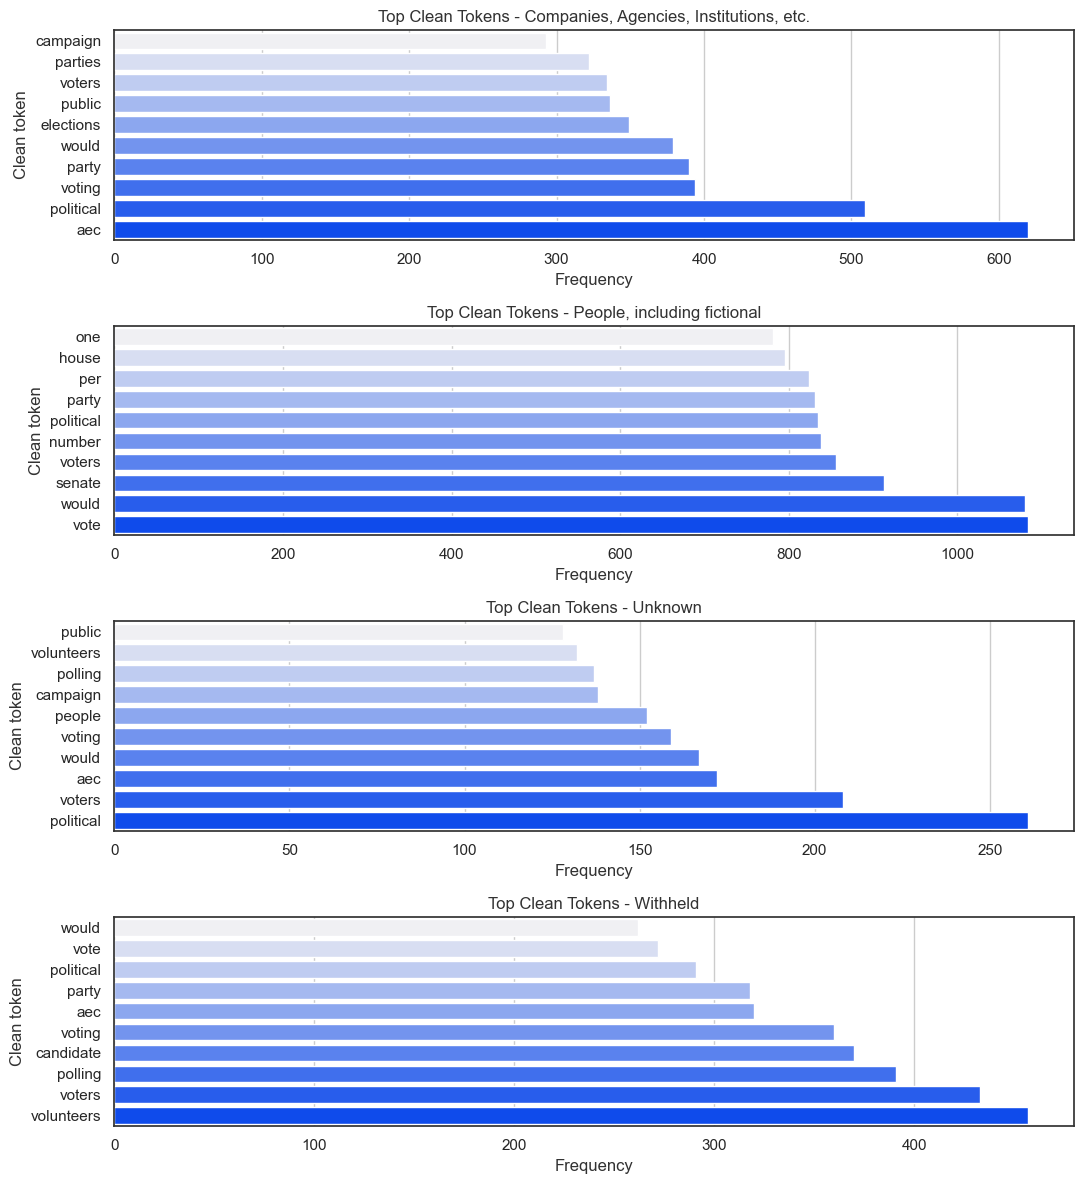

Top clean tokens by submitter type (top 10 each):


,submitter_type,word,count
0,"Companies, Agencies, Institutions, etc.",aec,620
1,"Companies, Agencies, Institutions, etc.",political,509
2,"Companies, Agencies, Institutions, etc.",voting,394
3,"Companies, Agencies, Institutions, etc.",party,390
4,"Companies, Agencies, Institutions, etc.",would,379
5,"Companies, Agencies, Institutions, etc.",elections,349
6,"Companies, Agencies, Institutions, etc.",public,336
7,"Companies, Agencies, Institutions, etc.",voters,334
8,"Companies, Agencies, Institutions, etc.",parties,322
9,"Companies, Agencies, Institutions, etc.",campaign,293


In [57]:
# 4.2 Visuals: most common words (clean tokens)

overall_word_counter = Counter(all_tokens)
top_words_df = pd.DataFrame(overall_word_counter.most_common(20), columns=["word", "count"])
plot_top_words = top_words_df.sort_values("count", ascending=True)

LOGGER.info("Clean token visualization prepared: unique_clean_tokens=%d", len(overall_word_counter))

# Chart 1: overall top clean tokens
visuals.bar(
    data=plot_top_words,
    x="count",
    y="word",
    color=UTS_PALETTE["blue"],
    title="Top 20 Most Common Clean Tokens (Corpus Overall)",
    xlabel="Frequency",
    ylabel="Clean token",
    figsize=(10, 6),
)

# Top clean tokens by submitter type
rows = []
for submitter_type, group_df in corpus_df.groupby("submitter_type"):
    type_tokens = [
        token
        for tokens in group_df["clean_tokens"]
        for token in tokens
    ]
    type_counter = Counter(type_tokens)
    for word, count in type_counter.most_common(10):
        rows.append({"submitter_type": submitter_type, "word": word, "count": count})

top_words_by_type_df = pd.DataFrame(rows)

# Chart 2: top clean tokens by submitter type (faceted)
submitter_types = list(top_words_by_type_df["submitter_type"].dropna().unique())
fig, axes = plt.subplots(
    nrows=len(submitter_types),
    ncols=1,
    figsize=(11, max(3 * len(submitter_types), 6)),
    sharex=False,
)

if len(submitter_types) == 1:
    axes = [axes]

for ax, submitter_type in zip(axes, submitter_types):
    type_data = (
        top_words_by_type_df[top_words_by_type_df["submitter_type"] == submitter_type]
        .sort_values("count", ascending=True)
    )

    sns.barplot(data=type_data, x="count", y="word", color=UTS_PALETTE["blue"], ax=ax)

    gradient_colors = sns.light_palette(UTS_PALETTE["blue"], n_colors=len(type_data))
    for bar, color in zip(ax.patches, gradient_colors):
        bar.set_facecolor(color)

    ax.set_title(f"Top Clean Tokens - {submitter_type}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Clean token")

plt.tight_layout()
plt.show()

print("Top clean tokens by submitter type (top 10 each):")
top_words_by_type_df.sort_values(["submitter_type", "count"], ascending=[True, False]).head(60)


**Analysis.** Because these charts use `clean_tokens`, the dominant terms are easier to interpret than raw-token counts and better reflect substantive inquiry themes rather than formatting noise or stopwords. The faceted comparison by `submitter_type` also makes it easier to see whether different groups emphasize the same cleaned vocabulary or whether each group foregrounds distinct concerns.


### 4.3 Corpus snapshot statistics

This cell reports compact EDA summary statistics used to frame the visual analysis.

In [58]:
# 4.3 Snapshot statistics

print("=== EDA Snapshot ===")
print(f"Documents analysed: {len(corpus_df)}")
print(f"Corpus vocabulary size (clean tokens): {vocab_size:,}")
print(f"Median document word count (raw): {corpus_df['word_count_raw'].median():.0f}")
print(f"Median lexical diversity: {corpus_df['lexical_diversity'].median():.3f}")

=== EDA Snapshot ===
Documents analysed: 299
Corpus vocabulary size (clean tokens): 16,666
Median document word count (raw): 815
Median lexical diversity: 0.660


### 4.4 Length comparison by submitter type

This visual compares raw and cleaned document lengths across submitter categories to show whether the same groups remain relatively longer after preprocessing.

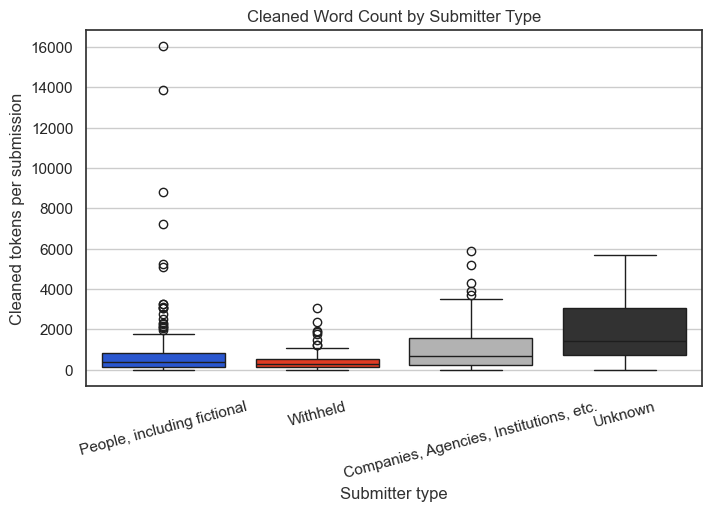

In [59]:
# 4.4 Visual: grouped comparison by submitter type (using clean tokens only)

submitter_order = corpus_df["submitter_type"].dropna().value_counts().index.tolist()
palette_cycle = [
    UTS_PALETTE["blue"],
    UTS_PALETTE["red"],
    UTS_PALETTE["mid_grey"],
    UTS_PALETTE["dark_grey"],
]
submitter_palette = {
    label: palette_cycle[idx % len(palette_cycle)]
    for idx, label in enumerate(submitter_order)
}

# Only plot cleaned word counts, since we want to focus on clean tokens
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

sns.boxplot(
    data=corpus_df,
    x="submitter_type",
    y="clean_word_count",
    order=submitter_order,
    hue="submitter_type",
    palette=submitter_palette,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Cleaned Word Count by Submitter Type")
ax.set_xlabel("Submitter type")
ax.set_ylabel("Cleaned tokens per submission")
ax.tick_params(axis="x", rotation=15)

plt.show()

**Analysis.** Comparing raw and cleaned word counts side by side shows whether preprocessing changes the relative size pattern across submitter types. If the same groups remain longer in both panels, that suggests the difference is structural to the submissions themselves rather than being caused mainly by removable stopwords, punctuation, or formatting noise.

### 4.5 Frequency table preparation (unigrams, NPMI bigrams, and NPMI trigrams)

This cell computes unigram frequencies from the cleaned token stream and phrase frequencies from the NPMI bigram and trigram outputs so the following charts can compare raw n-grams against detected phrase units.

In [60]:
# 4.5 Frequency tables

raw_unigram_counts = Counter(raw_all_tokens)
clean_unigram_counts = Counter(all_tokens)
raw_bigram_counts = TextAnalytics.compute_ngram_counts(corpus_df["raw_tokens"], n=2)
raw_trigram_counts = TextAnalytics.compute_ngram_counts(corpus_df["raw_tokens"], n=3)
npmi_bigram_counts = Counter(
    token.replace("_", " ")
    for tokens in corpus_df["pmi_bigram_tokens"]
    for token in tokens
    if token.count("_") == 1
)
npmi_trigram_counts = Counter(
    token.replace("_", " ")
    for tokens in corpus_df["pmi_trigram_tokens"]
    for token in tokens
    if token.count("_") == 2
)

top_raw_unigrams = pd.DataFrame(raw_unigram_counts.most_common(20), columns=["term", "count"])
top_clean_unigrams = pd.DataFrame(clean_unigram_counts.most_common(20), columns=["term", "count"])

top_raw_bigrams = pd.DataFrame(
    [(" ".join(bg), count) for bg, count in raw_bigram_counts.most_common(15)],
    columns=["bigram", "count"],
)
top_npmi_bigrams = pd.DataFrame(
    list(npmi_bigram_counts.most_common(15)),
    columns=["bigram", "count"],
)

top_raw_trigrams = pd.DataFrame(
    [(" ".join(tg), count) for tg, count in raw_trigram_counts.most_common(15)],
    columns=["trigram", "count"],
)
top_npmi_trigrams = pd.DataFrame(
    list(npmi_trigram_counts.most_common(15)),
    columns=["trigram", "count"],
)

print("Top 10 raw unigrams:")
display(top_raw_unigrams.head(10))

print("Top 10 clean unigrams:")
display(top_clean_unigrams.head(10))

print("Top 10 raw bigrams:")
display(top_raw_bigrams.head(10))

print("Top 10 NPMI bigram phrases:")
display(top_npmi_bigrams.head(10))

print("Top 10 raw trigrams:")
display(top_raw_trigrams.head(10))

print("Top 10 NPMI trigram phrases:")
display(top_npmi_trigrams.head(10))

Top 10 raw unigrams:


,term,count
0,the,34656
1,and,14763
2,that,6176
3,for,6019
4,election,5233
5,with,3244
6,this,3239
7,federal,3226
8,submission,2928
9,was,2862


Top 10 clean unigrams:


,term,count
0,political,1896
1,would,1888
2,voters,1831
3,aec,1815
4,vote,1751
5,voting,1666
6,party,1619
7,polling,1354
8,number,1353
9,one,1261


Top 10 raw bigrams:


...

,bigram,count
0,house representatives,513
1,per cent,503
2,joint standing,293
3,ballot paper,260
4,political advertising,249
5,polling booth,237
6,polling places,234
7,polling booths,233
8,fixed terms,214
9,social media,205


Top 10 raw trigrams:


,trigram,count
0,the federal election,2473
1,inquiry into the,2230
2,into the federal,2155
3,federal election submission,2037
4,the house representatives,374
5,joint standing committee,333
6,committee electoral matters,323
7,standing committee electoral,321
8,australian electoral commission,295
9,submission inquiry into,293


Top 10 NPMI trigram phrases:


,trigram,count
0,joint standing matters,222
1,truth political advertising,133
2,division ppvc total,81
3,votes days open,81
4,avg per day,81
5,new south wales,76
6,seats per cent,64
7,length parliamentary term,57
8,https accessed october,50
9,composition whole including,45


### 4.6 Top unigram frequency chart

These charts visualize the most common single-word terms in separate raw-token and cleaned-token views so the effect of preprocessing is easy to compare.

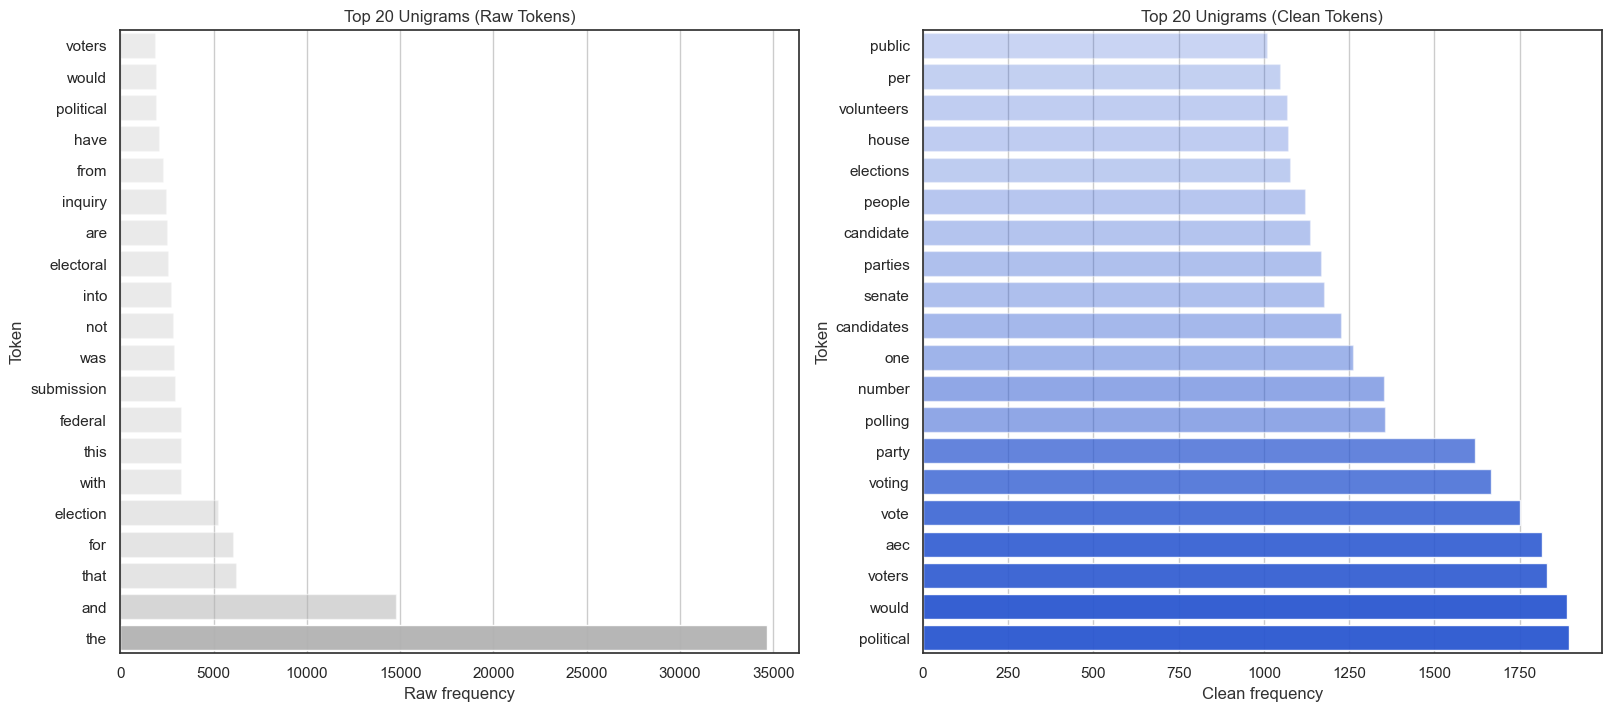

In [61]:
# 4.6 Visual: top unigrams

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_unigrams.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["mid_grey"],
    title="Top 20 Unigrams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Token",
    ax=axes[0],
)

visuals.bar(
    data=top_clean_unigrams.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["blue"],
    title="Top 20 Unigrams (Clean Tokens)",
    xlabel="Clean frequency",
    ylabel="Token",
    ax=axes[1],
)

plt.show()

**Analysis.** Showing raw and clean unigram charts separately makes the preprocessing effect more visible. The raw-token chart retains more general vocabulary, while the cleaned-token chart concentrates the language onto more interpretable inquiry themes. Terms such as `election`, `federal`, `submission`, `electoral`, `inquiry`, `political`, `voters`, `aec`, and `vote` indicate that the dataset remains strongly centered on electoral administration, public participation, and institutional process.

### 4.7 Top bigram frequency chart (using NPMI phrase output)

These charts compare frequent raw bigrams with the NPMI bigram phrases detected from the cleaned token stream so the effect of phrase modeling is easy to interpret.

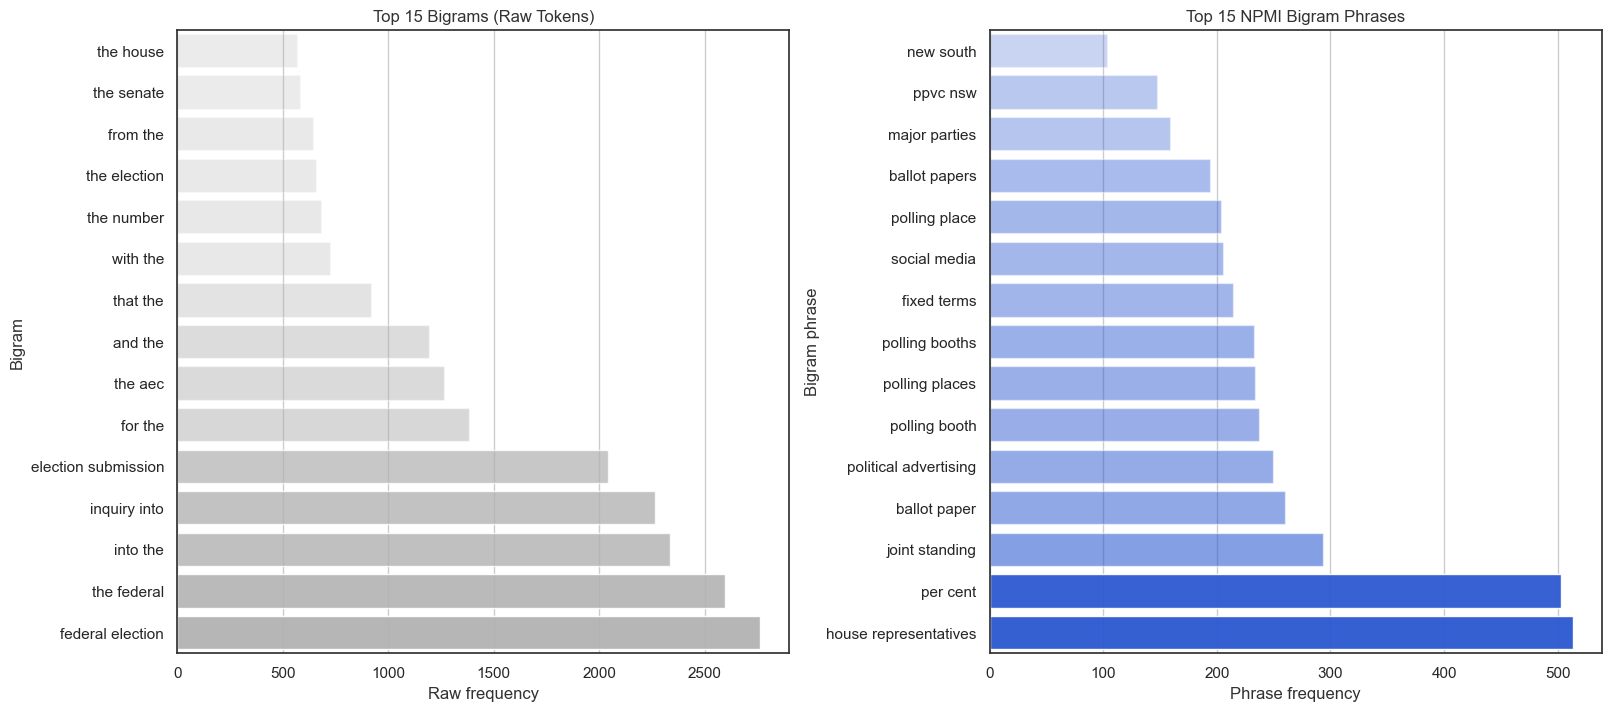

In [62]:
# 4.7 Visual: top bigrams

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_bigrams.sort_values("count", ascending=True),
    x="count",
    y="bigram",
    color=UTS_PALETTE["mid_grey"],
    title="Top 15 Bigrams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Bigram",
    ax=axes[0],
)

visuals.bar(
    data=top_npmi_bigrams.sort_values("count", ascending=True),
    x="count",
    y="bigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 NPMI Bigram Phrases",
    xlabel="Phrase frequency",
    ylabel="Bigram phrase",
    ax=axes[1],
)

plt.show()

**Analysis.** Bigrams add more context than single terms, and the NPMI phrase model highlights word pairs that cohere strongly enough to be treated as phrase-like units. Comparing raw bigrams with detected NPMI bigram phrases shows the difference between simple adjacency and more meaningful collocations, making recurring institutional and policy expressions easier to interpret.

### 4.8 Top three-gram frequency chart (using NPMI phrase output)

These charts compare frequent raw trigrams with the NPMI trigram phrases detected from the phrase-modeled token stream so longer recurring expressions are easier to interpret.

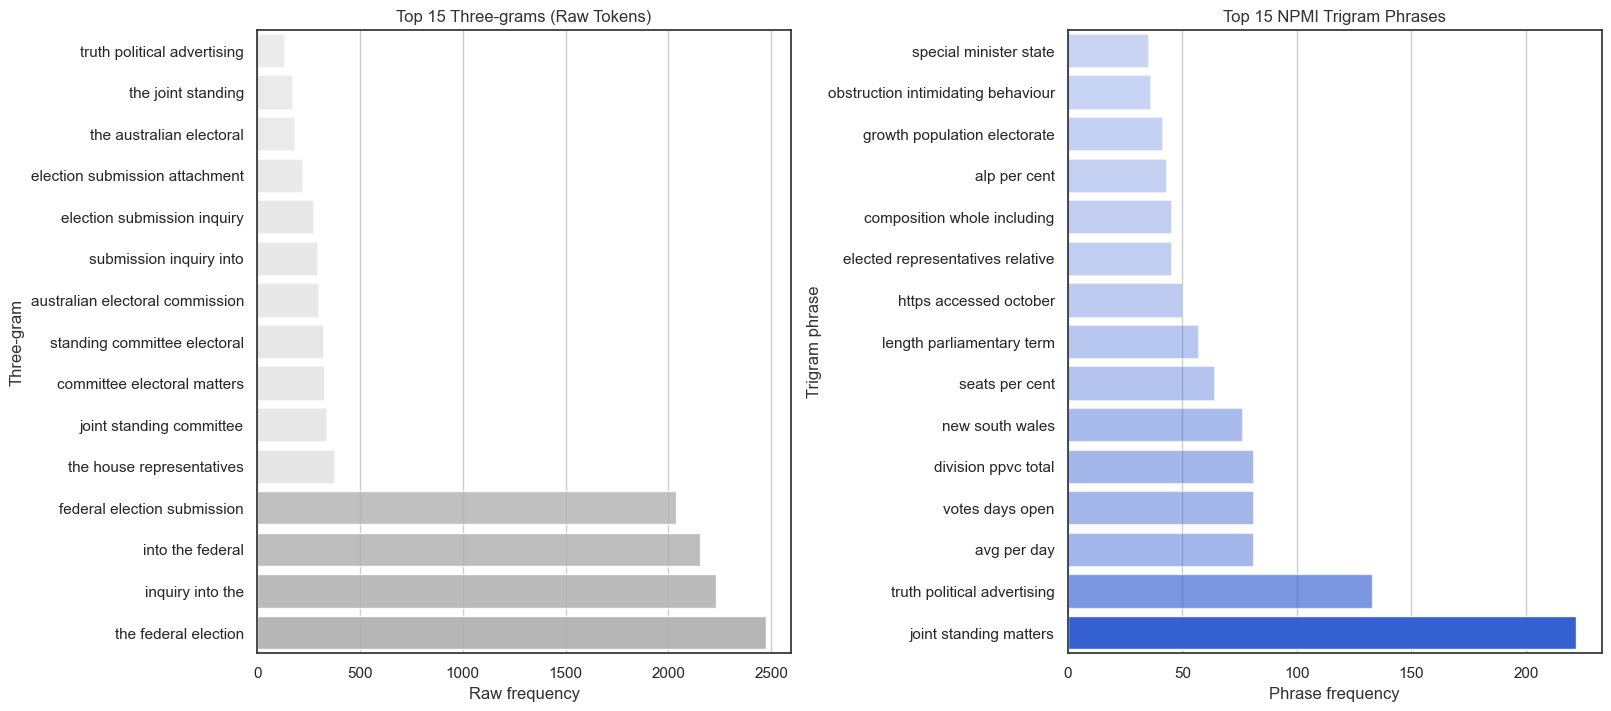

In [63]:
# 4.8 Visual: top three-grams

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_trigrams.sort_values("count", ascending=True),
    x="count",
    y="trigram",
    color=UTS_PALETTE["mid_grey"],
    title="Top 15 Three-grams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Three-gram",
    ax=axes[0],
)

visuals.bar(
    data=top_npmi_trigrams.sort_values("count", ascending=True),
    x="count",
    y="trigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 NPMI Trigram Phrases",
    xlabel="Phrase frequency",
    ylabel="Trigram phrase",
    ax=axes[1],
)

plt.show()

**Analysis.** NPMI trigrams are more selective than raw three-grams because they emphasize phrase-like expressions rather than any frequent three-word sequence. Comparing raw trigrams with detected NPMI trigram phrases makes it easier to identify stable multiword themes that can feed more interpretable downstream topic modeling and qualitative interpretation.

### 4.9 Initial preprocessing interpretation

Using the current extraction run, the corpus contains **299 submissions** with text successfully extracted from all files. Document lengths are highly variable (median around **815 words**), with **organisation submissions generally much longer** than individual and withheld-name submissions.

The cleaned corpus vocabulary is broad (about **16.7k unique tokens**) with median lexical diversity around **0.66**, indicating substantial variation in expression across submissions. High-frequency terms and bigrams such as *political*, *voters*, *AEC*, *house representatives*, and *political advertising* suggest that institutional process, electoral administration, and campaign regulation are dominant early themes.

These preprocessing findings motivate deeper analysis in the next sections to separate broad procedural language from distinct issue-specific concerns.

### 4.10 Word cloud of preprocessed corpus

This visual summary highlights the relative prominence of terms in the fully preprocessed corpus.

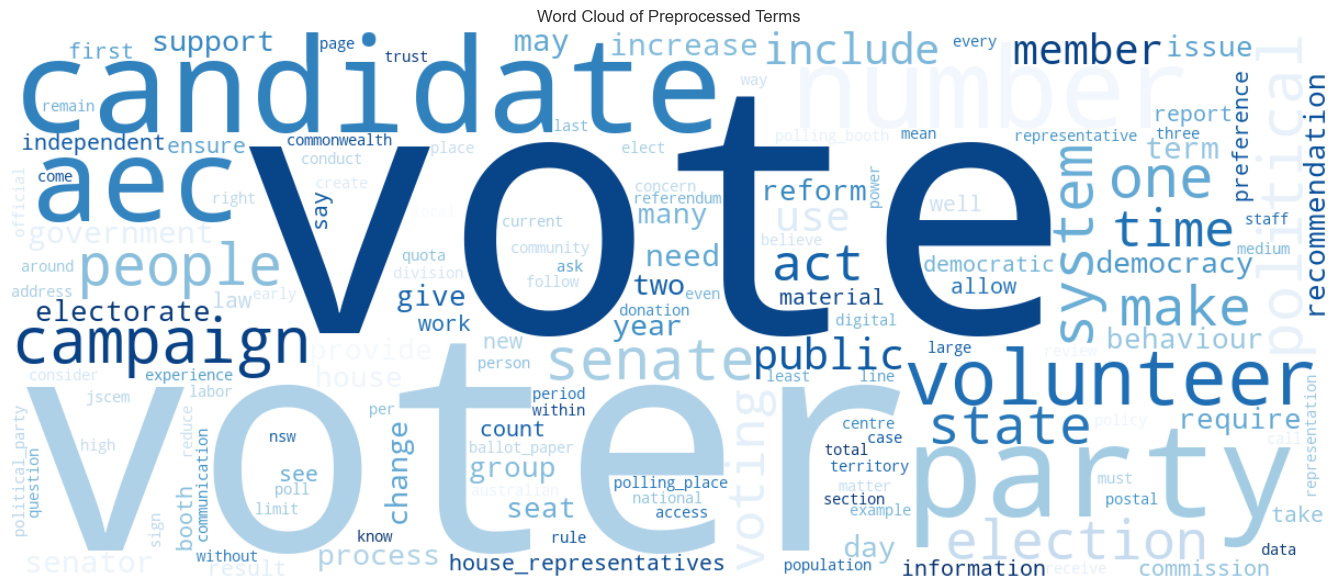

In [64]:
# 4.10 Word cloud

wordcloud_text = " ".join(corpus_df["preprocessed_text"].fillna(""))

visuals.wordcloud(
    text=wordcloud_text,
    title="Word Cloud of Preprocessed Terms",
    width=1200,
    height=500,
    max_words=150,
    colormap="Blues",
    background_color=UTS_PALETTE["white"],
    figsize=(14, 6),
)

**Analysis.** Unlike the ranked bar charts, the word cloud gives a fast holistic sense of vocabulary prominence and thematic concentration across the preprocessed corpus. It is useful for communication and pattern spotting, but precise comparisons should still rely on the frequency tables and bar charts because the size differences in a word cloud are only approximate.

### 4.11 Bigram network graph

This network graph visualizes the strongest bigram links in the lemmatized corpus so the co-occurrence structure between important terms is easier to inspect.

In [ ]:
# 4.11 Bigram network graph

lemmatized_network_tokens = [
    token
    for tokens in corpus_df["lemmatized_tokens"]
    if isinstance(tokens, list)
    for token in tokens
]

visuals.bigram_network(
    tokens=lemmatized_network_tokens,
    title="Bigram Network Graph of Lemmatized Tokens",
    n=50,
    figsize=(16, 12),
)

**Analysis.** Unlike the word cloud, the bigram network makes pairwise structure explicit by showing which lemmatized terms are connected most often across the corpus. Dense clusters and thick edges can highlight recurring policy expressions or institutional relationships that may not stand out as clearly in simple frequency-based charts.

<a id="topic-modeling"></a>

## 5. Advanced Methods (Topic Modeling / RegEx)

This section introduces model-based thematic extraction and pattern mining methods to move from descriptive frequencies toward structured insights.

### 5.1 Topic modeling with LDA

This cell builds an LDA model from the preprocessed corpus to identify latent themes and summarize each topic using high-probability terms.

In [ ]:
# 5.1 LDA topic modeling

vectorizer = CountVectorizer(max_df=0.9, min_df=5)
dtm = vectorizer.fit_transform(corpus_df["preprocessed_text"])
feature_names = vectorizer.get_feature_names_out()

n_topics = 6
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch",
    max_iter=20,
)
topic_distributions = lda_model.fit_transform(dtm)

topic_terms_df = TextAnalytics.extract_top_terms_per_topic(lda_model, feature_names, top_n=10)
LOGGER.info("LDA fitted: topics=%d, vocabulary=%d", n_topics, len(feature_names))
topic_terms_df

### 5.2 Topic prevalence across submissions

This cell assigns each submission to its dominant topic and visualizes topic prevalence to show which themes are most represented in the corpus.

In [ ]:
# 5.2 Topic prevalence

corpus_df["dominant_topic"] = topic_distributions.argmax(axis=1) + 1
topic_counts = (
    corpus_df["dominant_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic")
    .reset_index(name="count")
)

topic_counts["topic"] = topic_counts["topic"].astype(str).radd("Topic ")
LOGGER.info("Topic prevalence computed for %d submissions", len(corpus_df))

visuals.bar(
    data=topic_counts,
    x="topic",
    y="count",
    color=UTS_PALETTE["blue"],
    title="Dominant Topic Distribution Across Submissions",
    xlabel="Topic",
    ylabel="Number of submissions",
    figsize=(9, 5),
)

topic_counts

**Analysis.** This chart shows whether the corpus is dominated by a few broad themes or distributed across several discussion clusters. A strongly uneven profile would indicate concentrated attention on particular concerns, while a flatter spread would suggest the submissions cover a wider and more diverse policy agenda.

### 5.3 RegEx pattern mining

This cell extracts recurring structured references from submissions using regular expressions. Two examples are shown: year mentions and percentage mentions.

In [ ]:
# 5.3 Regex-based extraction

year_pattern = r"\b(?:19|20)\d{2}\b"
percentage_pattern = r"\b\d+(?:\.\d+)?%\b"

year_counts = TextAnalytics.extract_regex_counts(corpus_df["raw_text"], year_pattern).head(10)
percentage_counts = TextAnalytics.extract_regex_counts(corpus_df["raw_text"], percentage_pattern).head(10)
LOGGER.info("Regex extraction complete: years=%d unique, percentages=%d unique", len(year_counts), len(percentage_counts))

print("Top year references:")
display(year_counts.to_frame(name="count"))

print("Top percentage references:")
display(percentage_counts.to_frame(name="count"))

<a id="conclusion"></a>

## 6. Conclusion

Summarize your most important findings, directly answer the inquiry-focused questions, and briefly state:
- practical implications,
- limitations of the analysis,
- and recommended next steps for future work.

<a id="references"></a>

## 7. References

List all references used in this report (datasets, official sources, libraries, and academic/technical references), using one consistent citation style.